# 01 · Load & visualise a FIBO **Foundational** ontology — *without* the LPG load

This notebook reuses the ETL classes from **`ontology_to_lpg.py`**
(`RecursiveOntologyLoader` → `UniversalOntologyConverter`) to build the NetworkX
**meta-graph IR**, but deliberately **stops before `FalkorDBExporter`** — we only
*load* and *visualise* the schema; nothing is written to FalkorDB.

**Ontology:** `FND/Parties/Parties.rdf` — a core *Foundational* (FND) module
(Party, Party-in-Role, roles and relations) that most of FIBO builds on.

We load it with **`follow_imports=False`**, so we visualise this module's *own*
declared schema. Classes it references but does not define (e.g. imported
super-classes) appear as light-grey **`Resource`** stubs.

In [1]:
%matplotlib inline
import nb_helpers as h        # local module; wires in ../ontology_to_lpg.py
import pandas as pd

FIBO = h.find_fibo_root()
print("FIBO clone:", FIBO)

FIBO clone: C:\Users\marci\OneDrive\DEV\EDU\AIML\Graph ML\Ontology Engineering\Ontology Repository\FIBO\fibo


In [2]:
parties_file = FIBO / "FND" / "Parties" / "Parties.rdf"
ir = h.load_ontology_ir(parties_file, follow_imports=False)
print(f"IR: {ir.number_of_nodes()} nodes, {ir.number_of_edges()} edges")

IR: 17 nodes, 10 edges


## Schema summary

Node labels and edge types produced by the converter:

In [3]:
summary = h.summarize_ir(ir)
display(summary["labels"])
display(summary["edges"])

,node_label,count
0,OWLClass,6
1,ObjectProperty,3
2,Ontology,1
3,Resource,7


,edge_type,count
0,HAS_DOMAIN,1
1,HAS_RANGE,1
2,SUBCLASS_OF,5
3,SUBPROPERTY_OF,3


### The schema nodes (classes & properties defined here)

In [4]:
summary["nodes"][summary["nodes"].label != "Resource"].reset_index(drop=True)

,qname,label,rdfs_label,definition
0,cmns-cxtdsg:ContextualName,OWLClass,,
1,cmns-pts:Party,OWLClass,,
2,fibo-fnd-pty-pty:PartyRoleIdentificationScheme,OWLClass,party role identification scheme,system for allocating identifiers to roles tha...
3,fibo-fnd-pty-pty:PartyRoleIdentifier,OWLClass,party role identifier,"sequence of characters, capable of uniquely id..."
4,fibo-fnd-pty-pty:TaxIdentificationScheme,OWLClass,tax identification scheme,identification scheme used to identify taxpaye...
5,fibo-fnd-pty-pty:TaxIdentifier,OWLClass,tax identifier,identifier assigned to a taxpayer that enables...
6,fibo-fnd-pty-pty:hasMailingAddress,ObjectProperty,has mailing address,identifies a physical address where an indepen...
7,fibo-fnd-rel-rel:holds,ObjectProperty,,
8,fibo-fnd-rel-rel:isHeldBy,ObjectProperty,,
9,https://spec.edmcouncil.org/fibo/ontology/FND/...,Ontology,Parties Ontology,


## Visualise the meta-graph

Nodes are coloured by their LPG label (`OWLClass`, `ObjectProperty`, …) and edges
by relationship type (`SUBCLASS_OF`, `HAS_DOMAIN`, `HAS_RANGE`, `SUBPROPERTY_OF`).

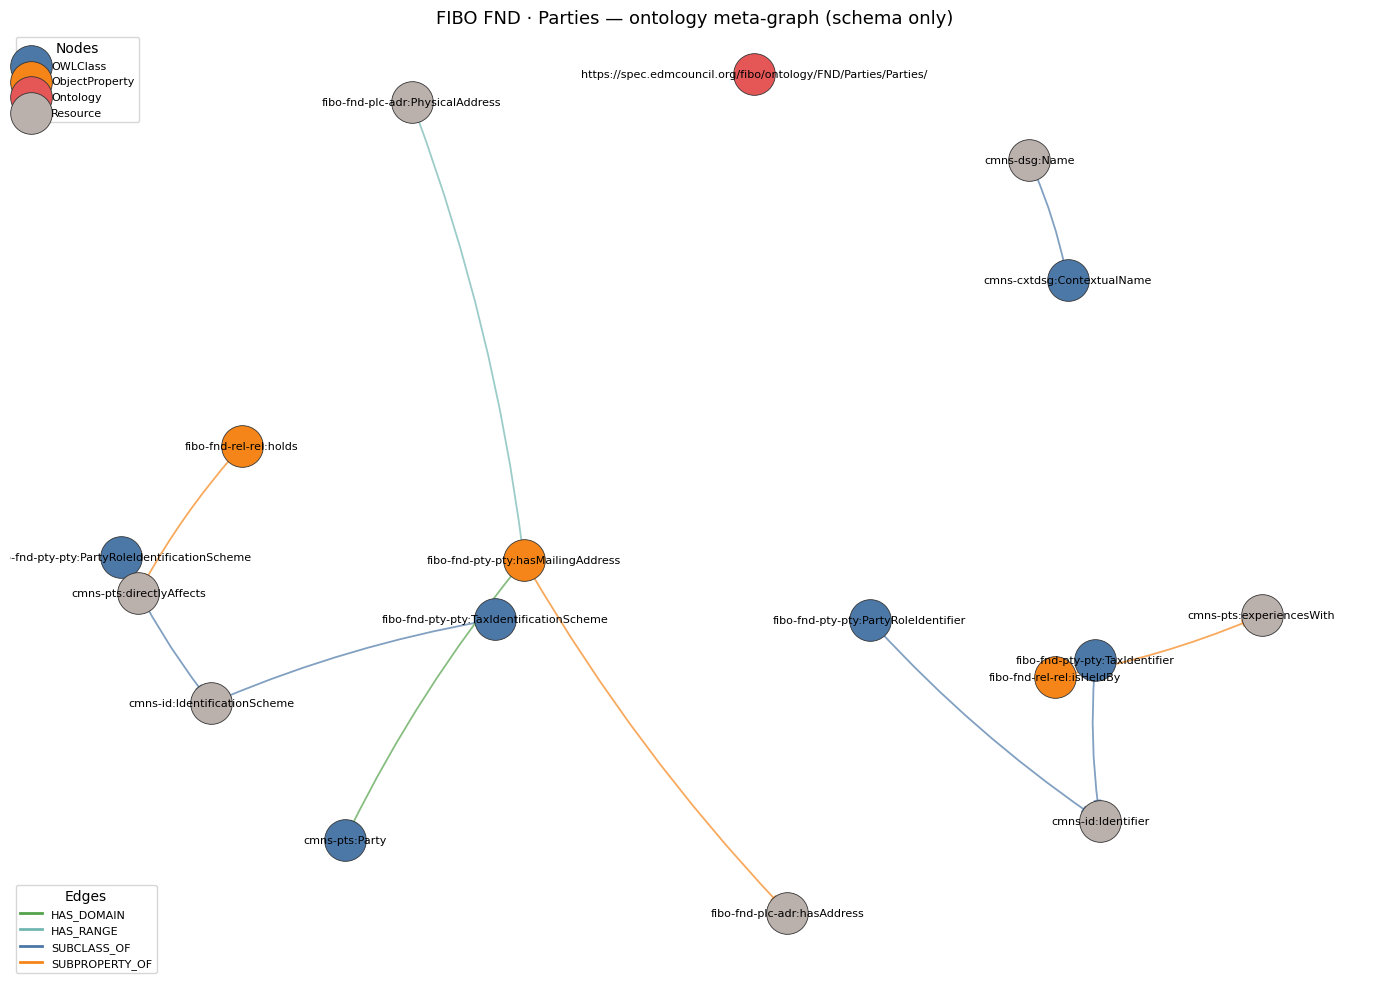

In [5]:
h.draw_meta_graph(ir, "FIBO FND · Parties — ontology meta-graph (schema only)",
                  color_by="label", figsize=(14, 10))

## Notes

* **No LPG export.** We never instantiate `FalkorDBExporter`; this is purely a
  load-and-look workflow on the in-memory NetworkX IR.
* **No `DEFINED_IN` edges.** FIBO does not use `rdfs:isDefinedBy`, so the lineage
  edges the converter *can* produce are absent here; the `(:Ontology)` node
  therefore stands on its own. Module membership is instead evident from the
  namespace prefix of each QName (`fibo-fnd-pty-pty:` …).
* **`Resource` stubs** are classes/properties referenced but not defined in this
  file (they live in imported modules). To resolve them, load with
  `follow_imports=True` and a local catalog:

  ```python
  from ontology_to_lpg import build_local_catalog
  catalog = build_local_catalog(FIBO)   # slow: parses the whole clone once
  ir_full = h.load_ontology_ir(parties_file, follow_imports=True,
                               uri_to_location=catalog)
  ```